<h1 align='center'>
1. Data Understanding
</h1>

## Overall Description

The dataset is contained in the file labelled `creditcard.csv` ([here](./creditcard.csv)). It was obtained from [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).

> **NB**: Instructions on how to properly load the data once you have cloned the repository are located in the [README](./README.md)

The dataset contains transactions made by credit cards in September 2013 by European cardholders.

It presents transactions that occurred in two days, where we have **492 frauds** out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for **0.172%** of all transactions.

It contains only numerical input variables, some of which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, the original features and more background information about the data were not provided.

## Features

Features **V1, V2,..., V28** are the principal components obtained with PCA. The only features which have not been transformed with PCA are **Time** and **Amount**.

**Time** contains the **seconds** elapsed between each transaction and the first transaction in the dataset.

**Amount** is the transaction amount, this feature can be used for example-dependant cost-sensitive learning. (The currency was not provided by Kaggle)

## Target

**Class** is the response variable and it takes value 1 in case of fraud and 0 otherwise.

---

<h1 align='center'>
2. Data Exploration
</h1>

In [2]:
import pandas as pd

data = pd.read_csv('./creditcard.csv')

data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
data.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(1081)

The data contains no null values and some duplicates. Let's view the duplicates:

In [6]:
import numpy as np

duplicates_indices = np.where(data.duplicated(keep=False).values)

data.iloc[duplicates_indices]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284190,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0
284192,172233.0,-2.691642,3.123168,-3.339407,1.017018,-0.293095,-0.167054,-0.745886,2.325616,-1.634651,...,0.402639,0.259746,-0.086606,-0.097597,0.083693,-0.453584,-1.205466,-0.213020,36.74,0


The above duplicates will need to be removed during data cleaning.

In [7]:
data[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


In [8]:
data['Time'].tail()

284802    172786.0
284803    172787.0
284804    172788.0
284805    172788.0
284806    172792.0
Name: Time, dtype: float64

On average, the transactions in the dataset are separated by **47,488 seconds** (around **13hrs**) from the mean with the last transaction happening **172,792 seconds** (around **2 days**) after the first.

In [9]:
data[data['Amount'] == 0]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
383,282.0,-0.356466,0.725418,1.971749,0.831343,0.369681,-0.107776,0.751610,-0.120166,-0.420675,...,0.020804,0.424312,-0.015989,0.466754,-0.809962,0.657334,-0.043150,-0.046401,0.0,0
514,380.0,-1.299837,0.881817,1.452842,-1.293698,-0.025105,-1.170103,0.861610,-0.193934,0.592001,...,-0.272563,-0.360853,0.223911,0.598930,-0.397705,0.637141,0.234872,0.021379,0.0,0
534,403.0,1.237413,0.512365,0.687746,1.693872,-0.236323,-0.650232,0.118066,-0.230545,-0.808523,...,-0.077543,-0.178220,0.038722,0.471218,0.289249,0.871803,-0.066884,0.012986,0.0,0
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.0,1
575,430.0,-1.860258,-0.629859,0.966570,0.844632,0.759983,-1.481173,-0.509681,0.540722,-0.733623,...,0.268028,0.125515,-0.225029,0.586664,-0.031598,0.570168,-0.043007,-0.223739,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283719,171817.0,-0.750414,0.904175,0.996461,0.427284,1.720336,0.929256,0.794272,0.176719,-1.836261,...,0.050750,0.115532,-0.623995,-0.186896,0.733759,2.558151,-0.188835,0.001654,0.0,0
283782,171870.0,2.083677,-0.065811,-1.442870,0.135416,0.043035,-1.306975,0.335835,-0.371635,0.730560,...,-0.147536,-0.246599,0.194758,-0.082277,0.012887,-0.069278,-0.048995,-0.065482,0.0,0
283949,172027.0,2.132569,-0.057836,-1.724522,-0.030326,0.412146,-0.903088,0.345843,-0.348132,0.722638,...,-0.188739,-0.343876,0.105024,-0.763831,0.117381,-0.027682,-0.047514,-0.071700,0.0,0
284085,172140.0,-2.210521,-1.039425,0.189704,-1.291932,3.742120,-1.665061,3.120388,-2.324089,0.364926,...,-0.286359,1.326003,-0.361764,-0.268117,1.051309,0.334629,-1.930149,-0.899888,0.0,0


Some transactions had an amount of **0**. This could be as a result of insufficient balance on the part of the credit card holder.

---

<h1 align='center'>
3. Data Cleaning
</h1>

Let's start by removing the duplicates identified during data inspection.

In [10]:
cleaned_data = data.drop_duplicates(ignore_index=True)

cleaned_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
cleaned_data.duplicated().sum()

np.int64(0)

Let us also split the data into **features** and **target**

In [12]:
features = cleaned_data.drop('Class', axis=1)
target = cleaned_data['Class']

features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     28

In [13]:
target.info()

<class 'pandas.core.series.Series'>
RangeIndex: 283726 entries, 0 to 283725
Series name: Class
Non-Null Count   Dtype
--------------   -----
283726 non-null  int64
dtypes: int64(1)
memory usage: 2.2 MB


---

<h1 align='center'>
4. Data Visualization
</h1>

## a) Class Imbalance

Let us visualize the class imbalance present in the dataset.

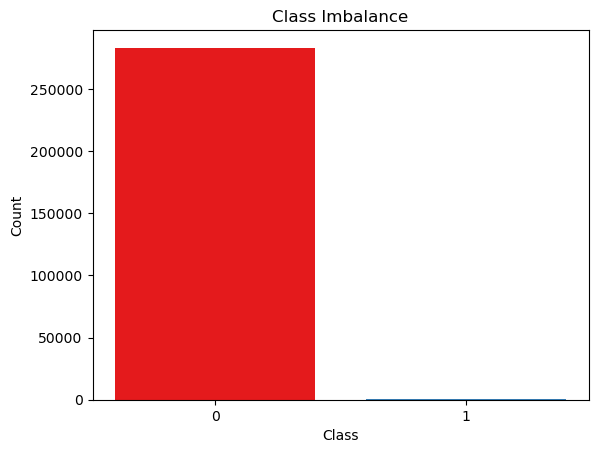

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

classes = cleaned_data['Class'].value_counts()
colors = sns.color_palette('Set1', n_colors=len(list(classes.keys())))

plt.bar(x=list(classes.keys()), height=list(classes.values), color=colors)

plt.title("Class Imbalance")
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1])

plt.show()

The number of fraudulent transactions is very low as indicated by the very short bar for 1 above. Let's use a logarithmic scale on y to make 1's bar more visible:

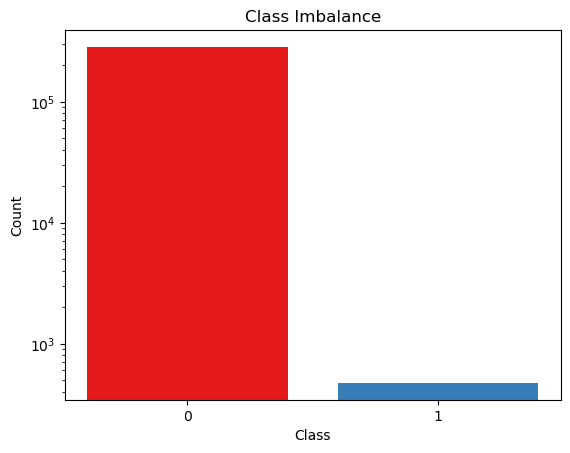

In [15]:
plt.bar(x=list(classes.keys()), height=list(classes.values), color=colors)

plt.title("Class Imbalance")
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1])
plt.yscale('log')

plt.show()

This helps make clear the sheer class imbalance the dataset suffers from. We will need to address this during modelling.

## b) Amount Distribution

Let us visualize how the different transaction amounts are distributed in the dataset.

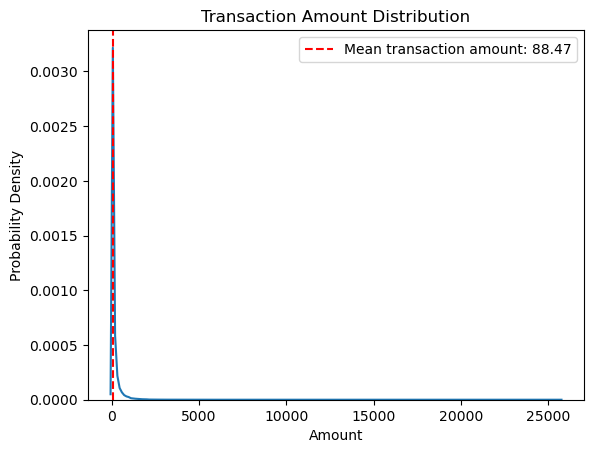

In [16]:
sns.kdeplot(cleaned_data['Amount'])
plt.axvline(cleaned_data['Amount'].mean(), linestyle='--', color='red', label=f"Mean transaction amount: {cleaned_data['Amount'].mean():.2f}")

plt.title("Transaction Amount Distribution")
plt.xlabel('Amount')
plt.ylabel("Probability Density")
plt.legend()

plt.show()

Most of the transaction amounts tend to cluster around the mean of **88** with higher amounts, such as 25,000 being very rare.

Let us also visualize the average amount of money for fraudulent vs genuine transactions.

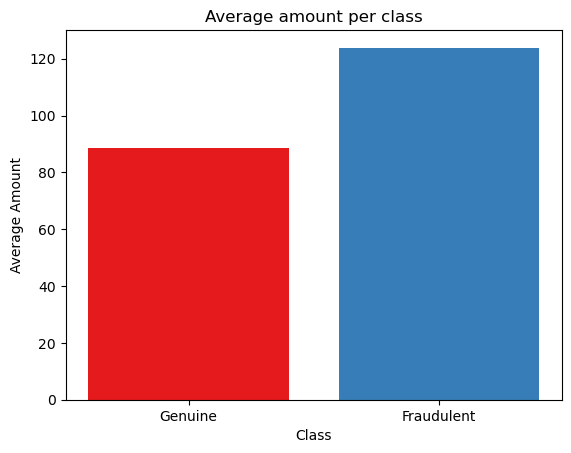

In [17]:
fraud_vs_genuine = cleaned_data[['Class', 'Amount']].groupby('Class').mean()
classes = list(fraud_vs_genuine.index)
amounts = list(fraud_vs_genuine.values.flatten())

plt.bar(x=classes, height=amounts, color=colors)

plt.xlabel('Class')
plt.ylabel("Average Amount")
plt.title("Average amount per class")
plt.xticks(ticks=[0, 1], labels=['Genuine', 'Fraudulent'])

plt.show()

On average, fraudulent transactions tend to be of higher amounts than genuine ones. This is to be expected, as the requests from criminals will almost always be for large sums of money.

This is something we hope the models will capture as a potential indicator that a transaction is fraudulent.

## c) Time Distribution

In this section, let's visualize the average time between transactions.

In [18]:
cleaned_data[['Time', 'Class']].head()

,Time,Class
0,0.0,0
1,0.0,0
2,1.0,0
3,1.0,0
4,2.0,0


In [19]:
gaps = []
classes = []

for index, row in cleaned_data[['Time', 'Class']].iterrows():
    if index == 0:
        gaps.append(row['Time'])
    else:
        gaps.append(row['Time'] - cleaned_data['Time'].iloc[index - 1])
    classes.append(row['Class'])

gap_df = pd.DataFrame({'Gap': gaps, 'Class': classes})

gap_df.head()

,Gap,Class
0,0.0,0.0
1,0.0,0.0
2,1.0,0.0
3,0.0,0.0
4,1.0,0.0


In [20]:
gap_df[gap_df['Class'] == 1].head()

,Gap,Class
534,0.0,1.0
616,0.0,1.0
4886,0.0,1.0
6072,0.0,1.0
6293,5.0,1.0


`gap_df` stores the gap in time between subsequent transactions. For example, the gap in time between the transactions at index 2 and 1 of `cleaned_data` is stored at index 2 of `gap_df` and is (1 minus 0) **1.0** seconds. The **Class** column stores the class of the current transaction taken from the **Class** column of `cleaned_data`.

With this dataframe, one can easily see that, for example, it took one second for the transaction at index 2 to happen after the transaction at index 1 occurred and that the former was a **genuine** transaction (since its class is **0**)

The transaction at index 534 took **0** seconds after the previous transaction and was **fraudulent**.

Let us now plot the probability density distribution for these gaps.

In [21]:
gap_df.describe()
# The largest gap is 32 seconds.

,Gap,Class
count,283726.000000,283726.000000
mean,0.609010,0.001667
std,1.054718,0.040796
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.000000
max,32.000000,1.000000


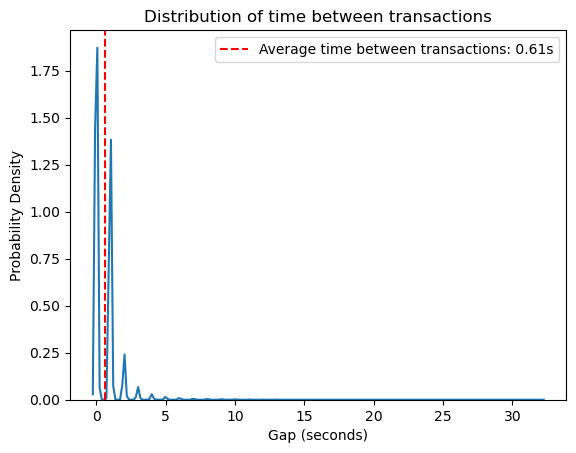

In [22]:
sns.kdeplot(gap_df['Gap'])

plt.xlabel('Gap (seconds)')
plt.ylabel('Probability Density')
plt.title('Distribution of time between transactions')
plt.axvline(gap_df['Gap'].mean(), linestyle='--', color='red', label=f"Average time between transactions: {gap_df['Gap'].mean():.2f}s")
plt.legend()

plt.show()

The plot shows peaks at whole number values for the gap. This is because the time values in `cleaned_data` were all integers, so their gaps would also be integers and the probability of finding decimal gaps is effectively 0.

The most frequent gap was **0 seconds**. 

> **NB**: This is not to mean that the transactions occurred at the same time. It just suggests that the level of granularity chosen to record the time (seconds) was not enough to show a clear separation between transactions. If the transaction times were recorded in milliseconds, for example, they might show that the transactions occurred at different times.

Larger gaps become less and less infrequent. Those larger gaps indicate periods when transaction traffic was low. This could be for any number of reasons e.g. it could have been at night when people were asleep or the system(s) experienced irregular downtime.

Let us try and visualize the average gap for fraudulent and genuine transactions.

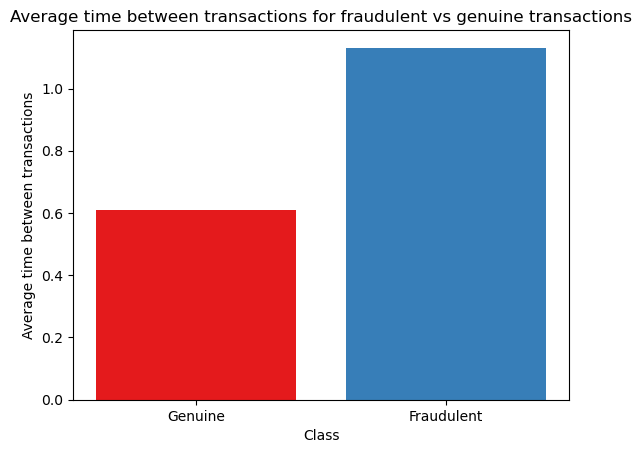

In [23]:
fraud_vs_genuine = gap_df.groupby('Class').mean()

plt.bar(x=fraud_vs_genuine.index, height=fraud_vs_genuine.values.flatten(), color=colors)

plt.xlabel('Class')
plt.ylabel('Average time between transactions')
plt.title("Average time between transactions for fraudulent vs genuine transactions")
plt.xticks(ticks=[0, 1], labels=['Genuine', 'Fraudulent'])

plt.show()

Fraudulent transactions tend to occur when transactions are happening **infrequently** i.e. the gap between transactions is high compared to genuine transactions. This could be due to any number of reasons.

This is something we hope the models will be able to capture.

<h1 align='center'>
5. Modelling
</h1>

We will try various models to see which predict the fraud cases most effectively. Since we are focusing on positive cases, **recall** will be the primary metric.

We will evaluate the following kinds of models:

a) **Logistic Regression** - This will be our baseline model. We will compare all the other models to this baseline.

b) **XGBoost** - This tree ensemble might prove effective at predicting.

c) **Random Forest** - Another tree ensemble

d) **Decision Tree** - A single decision tree

e) **Neural Network** - A collection of artificial neurons connected by weighted edges

At the end, we will have a **final evaluation** to see which model is the best.

The class imbalance we identified earlier will also need to be handled. We will do so through two methods and compare them:

a) **Using SMOTE** - This is **Synthetic Minority Oversampling Technique**. We will create artificial samples that reduce the class imbalance and give the models enough positive samples to train on.

b) **Class weights** - We will assign a higher penalty (weight) to false positives thus forcing the models to become better at predicting the positive class.

Let us first split the data into train and test sets. We will use a `random_state` for reproducibility. We will ensure that our training and test sets have the same proportion of positive (1) and negative (0) classes as in the overall dataset by setting `stratify` to **target**. This helps ensure that our test set does not randomly end up with all of the positive cases (however small that chance is).

We will also standardize the features using  `StandardScaler` to improve performance. It must, as usual, be fit on the training data only to avoid data leakage.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(features, target, random_state=2026, stratify=target, test_size=0.3)

scaler = StandardScaler()

X_train_scaled = pd. DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

X_train_scaled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.235054,0.626598,-0.058269,-0.468065,0.186209,1.394443,2.867465,-0.602657,0.819936,0.345129,...,-0.033860,-0.545605,-1.568876,0.121891,1.586548,1.000548,-1.260567,0.118046,0.080707,-0.318372
1,-0.411786,0.766122,-0.332702,-1.190074,-1.293642,1.385773,2.149265,-0.503342,0.496616,-1.173318,...,0.249071,0.190285,0.246477,-0.319671,1.724453,1.826377,-0.143587,-0.071404,-0.014963,-0.297824
2,1.168967,-0.153523,0.983079,-0.304617,0.752920,0.324453,-0.267019,0.324563,0.183350,-0.759314,...,0.480852,-0.298710,-0.628002,0.162304,1.046417,-1.657940,1.118620,0.492392,0.676745,-0.340169
3,-0.998198,0.613425,0.124919,0.411735,0.394481,-0.390037,-0.593900,-0.037847,-0.054443,-0.194889,...,-0.126461,-0.268410,-0.829579,0.242605,0.869606,0.301813,0.135558,-0.087643,0.032018,-0.353062
4,1.510310,1.065203,-0.993856,-0.074612,-0.985229,-1.511627,-0.629221,-1.182058,-0.017873,-1.070176,...,-0.502990,-0.406064,-0.752195,0.782315,0.762299,-1.448589,-1.120297,0.051351,-0.099624,-0.103667


<h2 align='center'>
a) Logistic Regression
</h2>

We will use **SMOTE** and **Class Weights** separately and compare to see which does best. We will also train a model with no class imbalance handling to see how it performs (that's 3 separate models). 

We will be using **sklearn**'s implementation of the logistic regression model. We will also grid search the best parameters for the logreg model.

To make the process as streamlined as possible, we will use **pipelines**.

### i) Unbalanced

> **NB**: The parameter list chosen was selected after playing around with different parameters. These were the ones that ran effectively on my machine, produced minimal warnings and decent scores. The following cell might take **~4** mins to run.

In [25]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import os
os.environ['PYTHONWARNINGS'] = 'ignore:pkg_resources is deprecated' # Suppress harmless pkg warning
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning) # Suppress ConvergenceWarning. Even higher max_iter and lower tolerances do nothing to fix it and just increase runtime

# Create pipeline
unbalanced_logreg_pipeline = Pipeline(
    [
        ('Logreg', LogisticRegression(random_state=2026, l1_ratio=0))
    ]
)

# Perform grid search
logreg_params = {
    'Logreg__max_iter': [100, 150, 200],
    'Logreg__fit_intercept': [True, False],
    'Logreg__solver': ['lbfgs', 'saga']
}

best_unbalanced_logreg_model = GridSearchCV(
    estimator=unbalanced_logreg_pipeline,
    param_grid=logreg_params,
    scoring=['recall', 'f1'],
    refit='f1',
    n_jobs=-2
)

# Fit on training data
best_unbalanced_logreg_model.fit(X_train_scaled, y_train)

# View results
unbalanced_logreg_results = pd.DataFrame(best_unbalanced_logreg_model.cv_results_)[['params', 'mean_test_recall', 'mean_test_f1', 'rank_test_recall', 'rank_test_f1']]

unbalanced_logreg_results[unbalanced_logreg_results['rank_test_f1'] == 1]

,params,mean_test_recall,mean_test_f1,rank_test_recall,rank_test_f1
6,"{'Logreg__fit_intercept': False, 'Logreg__max_...",0.800543,0.789173,1,1
8,"{'Logreg__fit_intercept': False, 'Logreg__max_...",0.800543,0.789173,1,1
10,"{'Logreg__fit_intercept': False, 'Logreg__max_...",0.800543,0.789173,1,1


In [26]:
best_unbalanced_logreg_model.best_params_

{'Logreg__fit_intercept': False,
 'Logreg__max_iter': 100,
 'Logreg__solver': 'lbfgs'}

**Not** fitting an intercept, having the maximum number of iterations as **100**, using the **lbfgs** solver, as well as using **l2** penalty, resulted in the highest recall and f1 score of **0.8** and **0.789** respectively.

### ii) SMOTE

> **NB**: The following cell might take **~7** mins to finish executing.

Notice the inclusion of the *SMOTER* into the pipeline.

In [27]:
from imblearn.over_sampling import SMOTE

# Create pipeline
SMOTE_logreg_pipeline = Pipeline(
    [
        ('SMOTER', SMOTE(random_state=2026)),
        ('Logreg', LogisticRegression(random_state=2026, l1_ratio=0))
    ]
)

# Perform grid search
best_SMOTE_logreg_model = GridSearchCV(
    estimator=SMOTE_logreg_pipeline,
    param_grid=logreg_params,
    scoring=['recall', 'f1'],
    refit='f1',
    n_jobs=-2
)

# Fit on training data
best_SMOTE_logreg_model.fit(X_train_scaled, y_train)

# View results
SMOTE_logreg_results = pd.DataFrame(best_SMOTE_logreg_model.cv_results_)[['params', 'mean_test_recall', 'mean_test_f1', 'rank_test_recall', 'rank_test_f1']]

SMOTE_logreg_results[SMOTE_logreg_results['rank_test_f1'] == 1]

,params,mean_test_recall,mean_test_f1,rank_test_recall,rank_test_f1
1,"{'Logreg__fit_intercept': True, 'Logreg__max_i...",0.906196,0.104841,7,1


In [28]:
best_SMOTE_logreg_model.best_params_

{'Logreg__fit_intercept': True,
 'Logreg__max_iter': 100,
 'Logreg__solver': 'saga'}

The logistic regression model trained using oversampled data yields a higher recall, compared to the unbalanced logistic regression model, of **0.906** but an abysmal f1 score of only **0.105**. This means the model has a very low **precision** score (as f1 score is the harmonic mean of precision and recall). A low precision score means the model has high number of **false positives**.

> **NB**: Increasing `max_iter` (up to 1000 at least) does nothing to improve the performance of the model and only increases runtime.

### iii) Class Weights

We will use class weights by setting the logistic regression class' `class_weight` parameter to **balanced**.

The following cell might take **~4** mins to run.

In [29]:
# Create pipeline
balanced_logreg_pipeline = Pipeline(
    [
        ('Logreg', LogisticRegression(random_state=2026, class_weight='balanced', l1_ratio=0))
    ]
)

# Perform grid search
best_balanced_logreg_model = GridSearchCV(
    estimator=balanced_logreg_pipeline,
    param_grid=logreg_params,
    scoring=['recall', 'f1'],
    refit='f1',
    n_jobs=-2
)

# Fit on training data
best_balanced_logreg_model.fit(X_train_scaled, y_train)

# View results
balanced_logreg_results = pd.DataFrame(best_balanced_logreg_model.cv_results_)[['params', 'mean_test_recall', 'mean_test_f1', 'rank_test_recall', 'rank_test_f1']]

balanced_logreg_results[balanced_logreg_results['rank_test_f1'] == 1]

,params,mean_test_recall,mean_test_f1,rank_test_recall,rank_test_f1
5,"{'Logreg__fit_intercept': True, 'Logreg__max_i...",0.903166,0.116257,7,1


In [30]:
best_balanced_logreg_model.best_params_

{'Logreg__fit_intercept': True,
 'Logreg__max_iter': 200,
 'Logreg__solver': 'saga'}

The best balanced model showcases a similar performance to the SMOTE model. It has a high recall of **0.903** but a poor precision of **0.116**. This indicates a high number of **false positives**. More on whether this is a good thing below.

### iv) Evaluation

In this section, we will evaluate all the logistic regression models **on the holdout test set** to identify the best logistic model for our purposes.

Let us start by looking at the classification reports for the models.

In [31]:
from sklearn.metrics import classification_report

print("Unbalanced:")
y_preds = best_unbalanced_logreg_model.predict(X_test_scaled)
print(classification_report(y_test, y_preds, digits=4))

print("\nSMOTE:")
y_preds = best_SMOTE_logreg_model.predict(X_test_scaled)
print(classification_report(y_test, y_preds, digits=4))

print("\nBalanced:")
y_preds = best_balanced_logreg_model.predict(X_test_scaled)
print(classification_report(y_test, y_preds, digits=4))

Unbalanced:
              precision    recall  f1-score   support

           0     0.9996    0.9996    0.9996     84976
           1     0.7801    0.7746    0.7774       142

    accuracy                         0.9993     85118
   macro avg     0.8899    0.8871    0.8885     85118
weighted avg     0.9993    0.9993    0.9993     85118


SMOTE:
              precision    recall  f1-score   support

           0     0.9998    0.9734    0.9865     84976
           1     0.0537    0.9014    0.1013       142

    accuracy                         0.9733     85118
   macro avg     0.5267    0.9374    0.5439     85118
weighted avg     0.9983    0.9733    0.9850     85118


Balanced:
              precision    recall  f1-score   support

           0     0.9998    0.9771    0.9883     84976
           1     0.0618    0.9014    0.1156       142

    accuracy                         0.9770     85118
   macro avg     0.5308    0.9393    0.5520     85118
weighted avg     0.9983    0.9770    0.9869

All of the models are very good at predicting genuine transactions, with extremely high precision, recall and f1-scores on the negative class (0).

However, the balanced and SMOTE models show poor precision scores on the positive class (which contributes to their poor f1-score as well) despite having very high recall on the same class. As stated earlier, this is a sign that the models have a high number of **false positives**. In the context of our application, this means the models flag a high number of genuine transactions as fraudulent.

The models having a higher recall, however, than the unbalanced model means they capture more of the fraudulent events at the expense of more false alarms.

This is something we are willing to tolerate as a false alarm is more manageable compared to a missed event.

Let us look at the confusion matrices for the models to get a clearer picture of their performances.

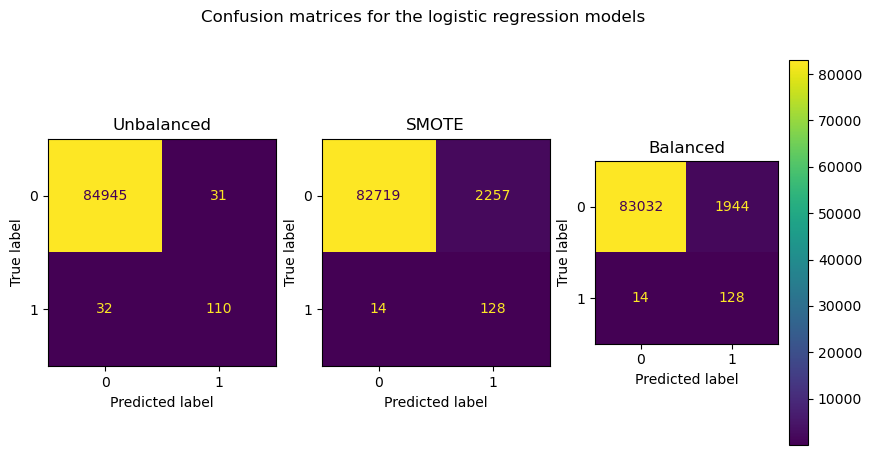

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

models = [best_unbalanced_logreg_model, best_SMOTE_logreg_model, best_balanced_logreg_model]
names = ["Unbalanced", "SMOTE", "Balanced"]

# Plot
fig, axs = plt.subplots(ncols=len(models), figsize=(10, 5))
for i, ax in enumerate(axs.flatten()):
    y_preds = models[i].predict(X_test_scaled)
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_preds))
    if i == len(models) -1:
        disp.plot(ax=ax, colorbar=True)
    else:
        disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{names[i]}")

fig.suptitle("Confusion matrices for the logistic regression models")
plt.show()

The unbalanced logistic model had a higher number of **false negatives** (missed events) compared to the SMOTE and balanced models. This is the metric we care about! A good model should be able to detect as many of the positive events as possible; that means have as **few false negatives** as possible.

The balanced model had fewer false positives (false alarms) compared to the SMOTE model while having the same number of true positives and false negatives. In other words, even though the SMOTE model had a higher number of false alarms, this did not translate to more captured events (true positives) when compared to the balanced model.

The balanced model is therefore the **best** logistic model as it captures the **most fraudulent events** with as **few false alarms** as possible.

Finally, let us take a look at the **ROC-AUC curve** for the models.

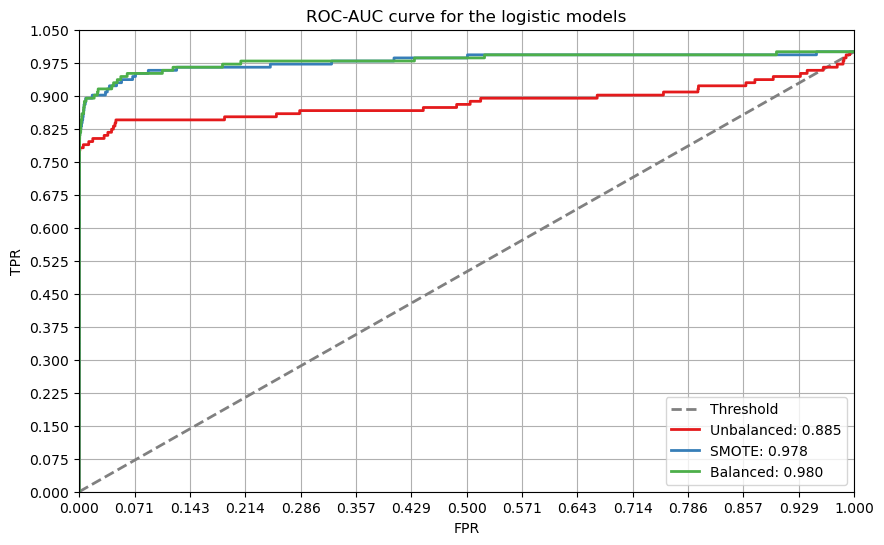

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

colors = sns.color_palette('Set1', n_colors=len(models))

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title("ROC-AUC curve for the logistic models")
ax.plot([0, 1], [0, 1], linestyle='--', linewidth=2, color='grey', label="Threshold")
ax.grid(True)
ax.set_xticks(np.linspace(0, 1, 15))
ax.set_yticks(np.linspace(0, 1.05, 15))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

for i, model in enumerate(models):
    y_scores = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    ax.plot(fpr, tpr, color=colors[i], linewidth=2, label=f"{names[i]}: {roc_auc_score(y_test, y_scores):.3f}")

ax.legend()
plt.show()

The **balanced** model has the highest **AUC** score of **0.98** further reinforcing our choice.

The balanced logistic model is the best logistic model and it is the model we shall be using as our baseline moving forward.

In [42]:
best_logistic_model = best_balanced_logreg_model

<h2 align='center'>
b) XGBoost
</h2>

### i) Unbalanced

The below cell will take about **~4** mins to run.

In [34]:
from xgboost import XGBClassifier

unbalanced_xgboost_pipeline = Pipeline(
    steps=[
        ('XGBoost', XGBClassifier(random_state=2026))
    ]
)

xgboost_params = {
    'XGBoost__n_estimators': [100, 150, 200],
    'XGBoost__max_depth': [2, 4, 6],
    'XGBoost__learning_rate': [0.01, 0.1, 0.3]
}

best_unbalanced_xgboost_model = GridSearchCV(
    estimator=unbalanced_xgboost_pipeline,
    param_grid=xgboost_params,
    scoring=['recall', 'f1'],
    refit='f1',
    n_jobs=-2
)

best_unbalanced_xgboost_model.fit(X_train_scaled, y_train)

unbalanced_xgboost_results = pd.DataFrame(best_unbalanced_xgboost_model.cv_results_)[['params', 'mean_test_recall', 'mean_test_f1', 'rank_test_recall', 'rank_test_f1']]

unbalanced_xgboost_results[unbalanced_xgboost_results['rank_test_f1'] == 1]

,params,mean_test_recall,mean_test_f1,rank_test_recall,rank_test_f1
13,"{'XGBoost__learning_rate': 0.1, 'XGBoost__max_...",0.785482,0.854323,4,1


In [35]:
best_unbalanced_xgboost_model.best_params_

{'XGBoost__learning_rate': 0.1,
 'XGBoost__max_depth': 4,
 'XGBoost__n_estimators': 150}

Using a learning_rate of 0.1, max_depth of 4, and 150 trees produced the best f1 score of **0.854** and a recall of **0.785**.

### ii) SMOTE

The following cell might take about **~8** mins to run.

In [36]:
SMOTE_xgboost_pipeline = Pipeline(
    steps=[
        ('SMOTER', SMOTE(random_state=2026)),
        ('XGBoost', XGBClassifier(random_state=2026))
    ]
)

best_SMOTE_xgboost_model = GridSearchCV(
    estimator=SMOTE_xgboost_pipeline,
    param_grid=xgboost_params,
    scoring=['recall', 'f1'],
    refit='f1',
    n_jobs=-2
)

best_SMOTE_xgboost_model.fit(X_train_scaled, y_train)

SMOTE_xgboost_results = pd.DataFrame(best_SMOTE_xgboost_model.cv_results_)[['params', 'mean_test_recall', 'mean_test_f1', 'rank_test_recall', 'rank_test_f1']]

SMOTE_xgboost_results[SMOTE_xgboost_results['rank_test_f1'] == 1]

,params,mean_test_recall,mean_test_f1,rank_test_recall,rank_test_f1
26,"{'XGBoost__learning_rate': 0.3, 'XGBoost__max_...",0.833786,0.826649,25,1


In [37]:
best_SMOTE_xgboost_model.best_params_

{'XGBoost__learning_rate': 0.3,
 'XGBoost__max_depth': 6,
 'XGBoost__n_estimators': 200}

Using a `learning_rate` of **0.3**, `max_depth` of **6** and `n_estimators` (number of trees) of **200** results in the best f1 score of **0.827** and recall of **0.834**

### iii) Balanced

Here, since `XGBClassifier` does not have the `class_weight` parameter, we compute the weight manually and assign it to the parameter `scale_pos_weight` that will scale the positive class using the ratio of the negative class to the positive class.

In [38]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

balanced_xgboost_pipeline = Pipeline(
    steps=[
        ('XGBoost', XGBClassifier(random_state=2026, scale_pos_weight=negative_count / positive_count))
    ]
)

best_balanced_xgboost_model = GridSearchCV(
    estimator=balanced_xgboost_pipeline,
    param_grid=xgboost_params,
    scoring=['recall', 'f1'],
    refit='f1',
    n_jobs=-2
)

best_balanced_xgboost_model.fit(X_train_scaled, y_train)

balanced_xgboost_results = pd.DataFrame(best_balanced_xgboost_model.cv_results_)[['params', 'mean_test_recall', 'mean_test_f1', 'rank_test_recall', 'rank_test_f1']]

balanced_xgboost_results[balanced_xgboost_results['rank_test_f1'] == 1]

,params,mean_test_recall,mean_test_f1,rank_test_recall,rank_test_f1
24,"{'XGBoost__learning_rate': 0.3, 'XGBoost__max_...",0.818634,0.858532,22,1


In [39]:
best_balanced_xgboost_model.best_params_

{'XGBoost__learning_rate': 0.3,
 'XGBoost__max_depth': 6,
 'XGBoost__n_estimators': 100}

Using a `learning_rate` of **0.3**, `max_depth` of **6** and `n_estimators` (number of trees) of **100** results in the best f1 score of **0.859** and recall of **0.819**

### iv) Evaluation

Let us look at the classification reports for the three models.

In [40]:
print("Unbalanced:")
y_preds = best_unbalanced_xgboost_model.predict(X_test_scaled)
print(classification_report(y_test, y_preds, digits=4))

print("\nSMOTE:")
y_preds = best_SMOTE_xgboost_model.predict(X_test_scaled)
print(classification_report(y_test, y_preds, digits=4))

print("\nBalanced:")
y_preds = best_balanced_xgboost_model.predict(X_test_scaled)
print(classification_report(y_test, y_preds, digits=4))

Unbalanced:
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     84976
           1     0.9217    0.7465    0.8249       142

    accuracy                         0.9995     85118
   macro avg     0.9607    0.8732    0.9123     85118
weighted avg     0.9994    0.9995    0.9994     85118


SMOTE:
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     84976
           1     0.8000    0.8169    0.8084       142

    accuracy                         0.9994     85118
   macro avg     0.8998    0.9083    0.9040     85118
weighted avg     0.9994    0.9994    0.9994     85118


Balanced:
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     84976
           1     0.9062    0.8169    0.8593       142

    accuracy                         0.9996     85118
   macro avg     0.9530    0.9084    0.9295     85118
weighted avg     0.9995    0.9996    0.9995

All the models perform well on the negative class.

The unbalanced model has high precision (**0.9217**) but relatively low recall (**0.7465**) on the positive class. This  might mean that it has a relatively low number of false positives (false alarms). It, however, has a relatively high number of false negatives (missed events) as evidenced by its relatively low recall on the positive class. This makes it a bad candidate for the best overall model.

The SMOTE model has a lower precision score (**0.8**) but a higher recall (**0.8169**) on the positive class. This means it has a higher number of false positives but a lower number of false negatives. This makes it a better model for our purposes.

The balanced model has a higher precision than the SMOTE model (**0.9062**) with a similar recall (**0.8169**) on the positive class. This means it has the same number of false negatives as the SMOTE model but fewer false alarms. This makes the **balanced model** the best of the three.

Let us take a look at their confusion matrices.

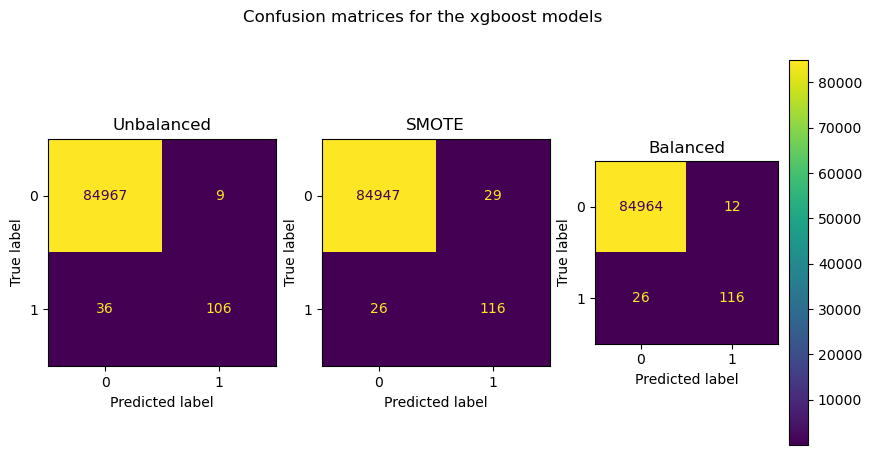

In [41]:
models = [best_unbalanced_xgboost_model, best_SMOTE_xgboost_model, best_balanced_xgboost_model]
names = ["Unbalanced", "SMOTE", "Balanced"]

# Plot
fig, axs = plt.subplots(ncols=len(models), figsize=(10, 5))
for i, ax in enumerate(axs.flatten()):
    y_preds = models[i].predict(X_test_scaled)
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_preds))
    if i == len(models) -1:
        disp.plot(ax=ax, colorbar=True)
    else:
        disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{names[i]}")

fig.suptitle("Confusion matrices for the xgboost models")
plt.show()

We can see that, as said earlier, the unbalanced model has a low number of false positives but a high number of false negatives. Since missed events (false negatives) are more costly than false alarms, the unbalanced model is **NOT** the model to go with.

As we saw earlier, the balanced model has the same number of false negatives as the SMOTE model with fewer false positives (**12** vs **29**). It offers similar capability of catching fraudulent events as the SMOTE model but with less false alarms.

The confusion matrices confirm that the **balanced model** is the best model for our purposes.

Let us finally take a look at the **ROC-AUC** curves for the models. 

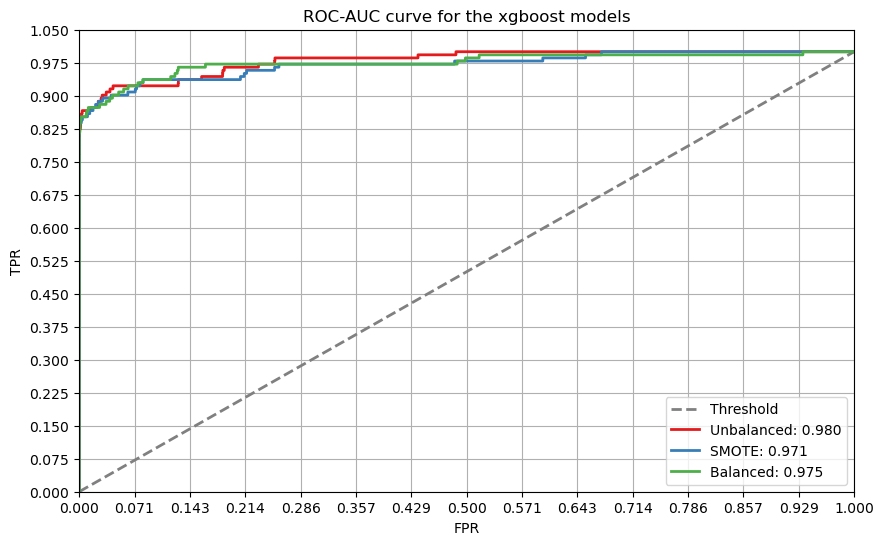

In [43]:
colors = sns.color_palette('Set1', n_colors=len(models))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title("ROC-AUC curve for the xgboost models")
ax.plot([0, 1], [0, 1], linestyle='--', linewidth=2, color='grey', label="Threshold")
ax.grid(True)
ax.set_xticks(np.linspace(0, 1, 15))
ax.set_yticks(np.linspace(0, 1.05, 15))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
for i, model in enumerate(models):
    y_scores = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    ax.plot(fpr, tpr, color=colors[i], linewidth=2, label=f"{names[i]}: {roc_auc_score(y_test, y_scores):.3f}")

# Display
ax.legend()
plt.show()

The unbalanced model has the highest auc score of the three (**0.980**). This might be because it can reliably correctly classify the genuine events as evidenced by its low number of false positives.

In a close second is the balanced model (**0.975**), which had the second-lowest number of false positives.

Third is the SMOTE model (**0.971**) which had the most false positives.

The **balanced model** is still the best model as it minimizes the number of false negatives with minimal false positives (and has a decent AUC score).